# Chapter 8: SciPy

## Notes

### SciPy Overview

- SciPy is a package that builds on
  [NumPy](../Chapter_07/Chapter_07.qmd) to enable scientific computing
- Provides specialised submodules for different functionality,
  including,
  - Optimisation
  - Fourier Transformations
  - Signal Processing
  - Linear Algebra
  - Image Processing
  - Statistics
  - and more…
- SciPy and NumPy are often paired with MatplotLib for visualisation
- Unlike `NumPy` there is no accepted shorthand for importing however
  `import scipy as sp` is used fairly often in practice

### The `scipy.misc` Submodule

- Contains functions that don’t below in a more broader submodule
- Some of these are just special demo functions
  - For example, `face` and `ascent`
  - These now live in the `scipy.datasets`
  - Require the optional `pooch` package

> **Important**
>
> **`misc` Deprecation**
>
> Scipy has deprecated `misc` and it is planned for removal in Scipy
> 2.0. All the functionality of `misc` has been removed. For example the
> `face` and `ascent` functions now live in `scipy.datasets`

[[[121 112 131]
  [138 129 148]
  [153 144 165]
  ...
  [119 126  74]
  [131 136  82]
  [139 144  90]]

 [[ 89  82 100]
  [110 103 121]
  [130 122 143]
  ...
  [118 125  71]
  [134 141  87]
  [146 153  99]]

 [[ 73  66  84]
  [ 94  87 105]
  [115 108 126]
  ...
  [117 126  71]
  [133 142  87]
  [144 153  98]]

 ...

 [[ 87 106  76]
  [ 94 110  81]
  [107 124  92]
  ...
  [120 158  97]
  [119 157  96]
  [119 158  95]]

 [[ 85 101  72]
  [ 95 111  82]
  [112 127  96]
  ...
  [121 157  96]
  [120 156  94]
  [120 156  94]]

 [[ 85 101  74]
  [ 97 113  84]
  [111 126  97]
  ...
  [120 156  95]
  [119 155  93]
  [118 154  92]]]

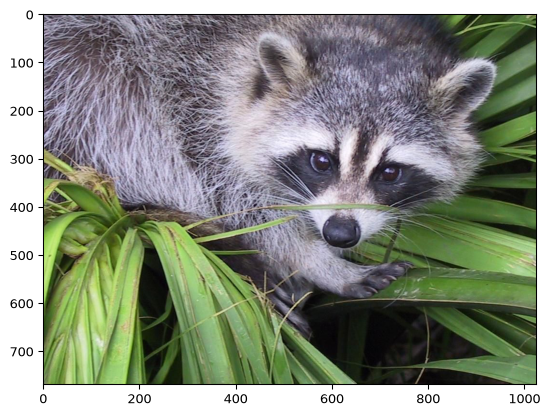

In [1]:
from scipy import datasets
import matplotlib.pyplot as plt

face = datasets.face()
print(face)

plt.imshow(face)
plt.show()

- And doing the same for `ascent`

[[ 83  83  83 ... 117 117 117]
 [ 82  82  83 ... 117 117 117]
 [ 80  81  83 ... 117 117 117]
 ...
 [178 178 178 ...  57  59  57]
 [178 178 178 ...  56  57  57]
 [178 178 178 ...  57  57  58]]

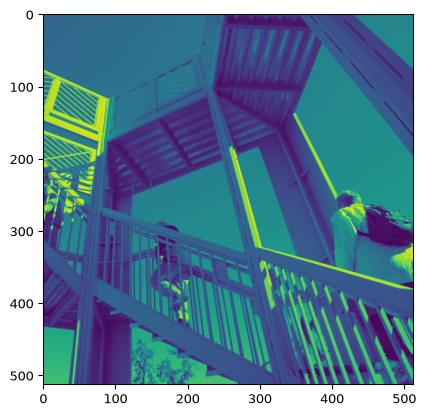

In [2]:
from scipy import datasets
import matplotlib.pyplot as plt

ascent = datasets.ascent()
print(ascent)

plt.imshow(ascent)
plt.show()

- `face` and `ascent` return NumPy arrays representing an image.
- The `imshow` function from `matplotlib.pyplot` can be used to plot an
  image

### The `scipy.special` Submodule

- `scipy.special` contains special functions commonly used in
  mathematical physics, including
  - Airy functions,
  - Bessel functions,
  - Elliptical functions,
  - Struve functions,
  - and more
- These functions are designed to operate with NumPy arrays
  - Support broadcasting
- For example,

In [3]:
from scipy import special

print("special.factorial(3):", special.factorial(3))
print("Combinations:", special.comb(10, 2))
print("Permutations:", special.perm(10, 2))

special.factorial(3): 6.0
Combinations: 45.0
Permutations: 90.0

> **Caution**
>
> **`scipy.special.stats` vs `scipy.stats`**
>
> `scipy.special` contains a `stats` submodule. This is not designed for
> direct use. Instead the `scipy.stats` module should be preferred

### The `scipy.stats` Submodule

- Provides probability distributions and statistical functions

#### Discrete Distributions

- Scipy offers several discrete distributions
- Each provides a common interface
- For example, demonstrating with a binomial distribution

B.pmf(2): 0.027845872524268643
B.cdf(4): 0.23750777887760136
B.mean(): 6.0
B.std(): 2.04939015319192
B.rvs(): 7
B.rvs(15): [ 6  7  8 13  6  3  8  6  4  4 10 11 10  7 10]

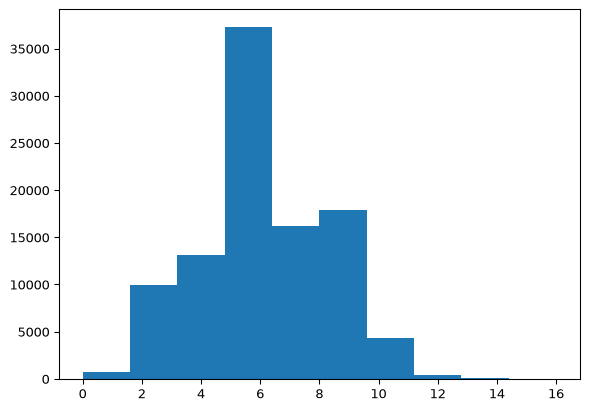

In [4]:
from scipy import stats
import matplotlib.pyplot as plt

B = stats.binom(20, 0.3)  # 20 trials with a 30% success chance

print("B.pmf(2):", B.pmf(2)) # Probability mass function P(x == 2)

print("B.cdf(4):", B.cdf(4)) # Cumulative density function (P x < 4)

print("B.mean():", B.mean()) # Mean

print("B.std():", B.std()) # Std-dev

print("B.rvs():", B.rvs()) # Get a random sample from the distribution

print("B.rvs(15):", B.rvs(15)) # Get 15 random samples from the distribution

# Plotting a large sampling of the distribution
samples = B.rvs(size=100_000)
plt.hist(samples)
plt.show()

- Another discrete distribution is the Poisson Distribution
  - Models the probability of a certain number of events happening
  - Shape of the distribution is controlled by the mean
    - Set via the `mu` keyword
    - A low mean skews the distribution left
    - A high mean pushes the distribution right
- A left-skewed distribution

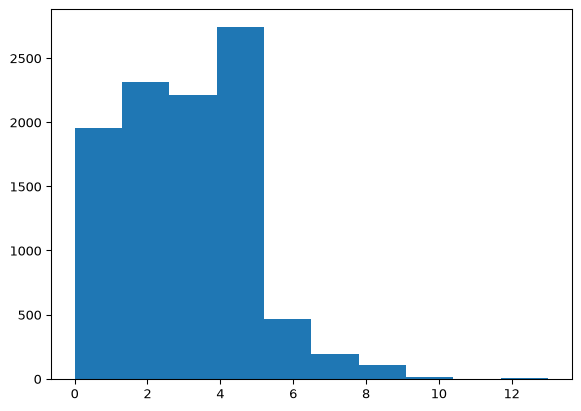

In [5]:
from scipy import stats
import matplotlib.pyplot as plt

P = stats.poisson(mu=3)
samples = P.rvs(size=10_000)
plt.hist(samples)
plt.show()

- A right-shifted distribution

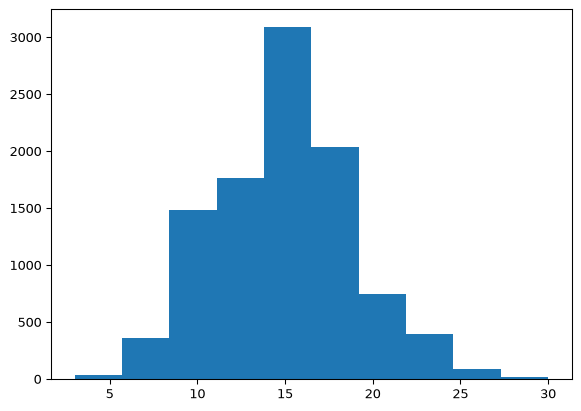

In [6]:
from scipy import stats
import matplotlib.pyplot as plt

P = stats.poisson(mu=15)
samples = P.rvs(size=10_000)
plt.hist(samples)
plt.show()

- There are number of further discrete distributions provided by
  `scipy.stats` including,
  - Beta-binomial,
  - Boltzmann (Truncated Planck),
  - Planck (Discrete Exponential),
  - Geometric,
  - Hyper-geometric,
  - Logarithmic,
  - Yule-Simon,
  - and more

#### Continuous Distributions

- Scipy also supports continuous distributions
  - There are more continuous distributions supported than there are
    discrete
- Like discrete distributions they all have a common interface
  - Take arguments for *location* (`loc`) and *scale* (`scale`)
    - By default, the location is $0$ and the scale is $1$
- For example, a common continuous distribution is the normal
  distribution

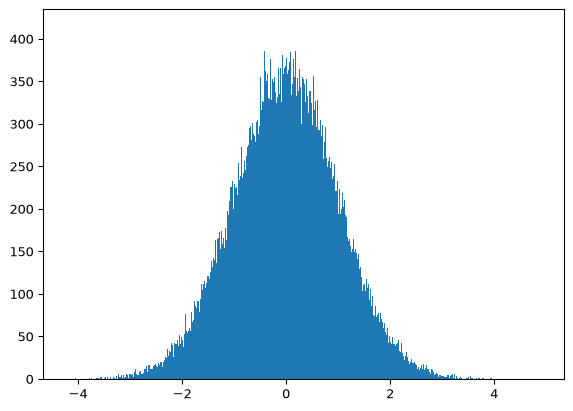

In [7]:
from scipy import stats
import matplotlib.pyplot as plt

N = stats.norm() # a Normal Distribution located at `0` and with scale `1`
samples = N.rvs(size=100_000)
plt.hist(samples, bins=1000)
plt.show()

- As we change the `loc` and `scale` parameters the distribution will
  change too

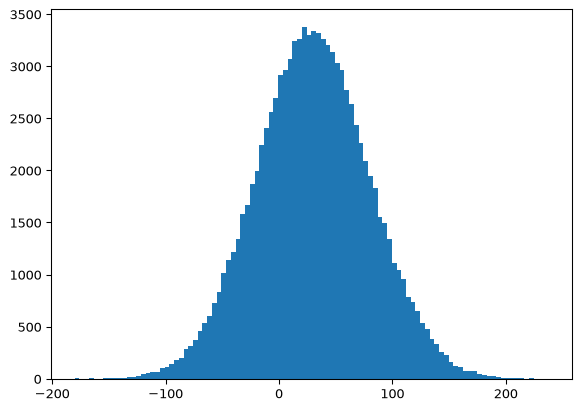

In [8]:
from scipy import stats
import matplotlib.pyplot as plt

N = stats.norm(loc=30, scale=50)
samples = N.rvs(size=100_000)
plt.hist(samples, bins=100)
plt.show()

- As mentioned continuous distributions have a common interface

In [9]:
from scipy import stats

N = stats.norm(loc=30, scale=50)

print("N.mean():", N.mean())

print("N.pdf(4):", N.pdf(4)) # Probability Density Function

print("N.cdf(2):", N.cdf(2)) # Cumulative density function

print("N.rvs():", N.rvs()) # Random sample from the distribution

print("N.var():", N.var()) # Variance

print("N.median():", N.median()) # Median

print("N.std():", N.std()) # Standard Deviation

N.mean(): 30.0
N.pdf(4): 0.006969850255179491
N.cdf(2): 0.28773971884902705
N.rvs(): 83.65732527711886
N.var(): 2500.0
N.median(): 30.0
N.std(): 50.0

- A continuous analogue to the Poisson Distribution is the exponential
  distribution

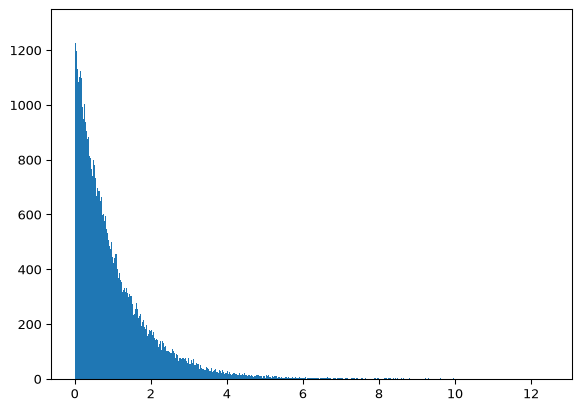

In [10]:
from scipy import stats
import matplotlib.pyplot as plt

E = stats.expon()
samples = E.rvs(size=100_000)
plt.hist(samples, bins=1_000)
plt.show()

- We can also use a uniform distribution

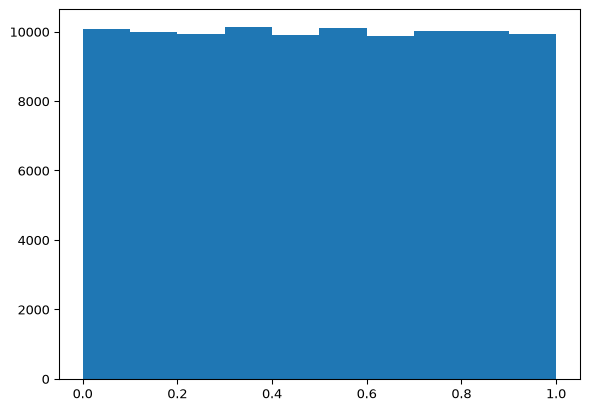

In [11]:
from scipy import stats
import matplotlib.pyplot as plt

U = stats.uniform()
samples = U.rvs(size=100_000)
plt.hist(samples)
plt.show()

## Summary

- Scipy extend NumPy with specialised functionality for complex
  scientific computing

## Questions

1.  Use the `scipy.stats` module to model a Normal distribution with a
    mean of 15

    ``` python
     from scipy import stats

     U = stats.normal(location=15)
    ```

2.  Generate $25$ random samples from the distribution modelled in
    Question 1

    ``` python
     from scipy import stats

     U = stats.normal(location=15)
     samples = U.rvs(25)
    ```

3.  Which SciPy module has utilities designed for mathematical physics?

    - Special functions like those used in mathematical physics are
      stored in `scipy.special`

4.  What method is provided with a discrete distribution to calculate it
    standard deviation?

    - The standard deviation can be found with the `.std` method

See answers implemented below

Q1
U.mean() = 15.0
Q2
[15.36589089 13.96437435 13.74361272 14.8336903  15.00670923 14.71526983
 15.74968844 14.692824   13.81136484 14.38717903 15.39530232 16.5492079
 15.09894662 15.16488033 16.03576896 14.35861129 14.81368908 14.59926824
 15.50801688 16.2851681  16.21819587 15.62255185 13.16040879 14.98026074
 15.35448602]

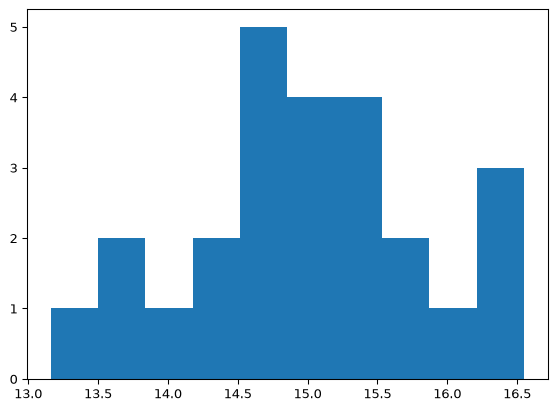

Q4
Standard Deviation: 2.04939015319192

In [12]:
from scipy import stats
import matplotlib.pyplot as plt

U = stats.norm(loc=15)
print("Q1\nU.mean() =", U.mean())

print("Q2")
samples = U.rvs(25)
print(samples)
plt.hist(samples)
plt.show()

print("Q4")
V = stats.binom(20, 0.3)
print("Standard Deviation:", V.std())